In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, make_scorer

SEED = 42

In [3]:
data = load_breast_cancer()
X_df = pd.DataFrame(data.data, columns=data.feature_names)
y_series = pd.Series(data.target)

print(f"Registros totales: {X_df.shape[0]}")
print(f"Características predictoras: {X_df.shape[1]}")
print(f"Valores faltantes: {X_df.isnull().sum().sum()}")
print(f"Duplicados: {X_df.duplicated().sum()}")

counts = y_series.value_counts()
print(f"Casos Benignos (clase 1): {counts[1]} ({counts[1]/len(y_series)*100:.2f}%)")
print(f"Casos Malignos (clase 0): {counts[0]} ({counts[0]/len(y_series)*100:.2f}%)")

Registros totales: 569
Características predictoras: 30
Valores faltantes: 0
Duplicados: 0
Casos Benignos (clase 1): 357 (62.74%)
Casos Malignos (clase 0): 212 (37.26%)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y_series,
    test_size=0.20,
    random_state=SEED,
    stratify=y_series
)

print(f"Entrenamiento (80%): {X_train.shape[0]} registros - {X_train.shape[1]} características")
print(f"Prueba (20%): {X_test.shape[0]} registros - {X_test.shape[1]} características")

Entrenamiento (80%): 455 registros - 30 características
Prueba (20%): 114 registros - 30 características


In [5]:
start_time = time.time()
rf_base = RandomForestClassifier(random_state=SEED)
rf_base.fit(X_train, y_train)
time_base = time.time() - start_time

y_pred_base = rf_base.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
recall_mal_base = recall_score(y_test, y_pred_base, pos_label=0)

print(f"Tiempo de entrenamiento: {time_base:.3f} s")
print(f"Accuracy: {acc_base*100:.2f}%")
print(f"Recall maligno (Clase 0): {recall_mal_base*100:.2f}%\n")
print(classification_report(y_test, y_pred_base, target_names=['Maligno', 'Benigno']))

Tiempo de entrenamiento: 0.554 s
Accuracy: 95.61%
Recall maligno (Clase 0): 92.86%

              precision    recall  f1-score   support

     Maligno       0.95      0.93      0.94        42
     Benigno       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



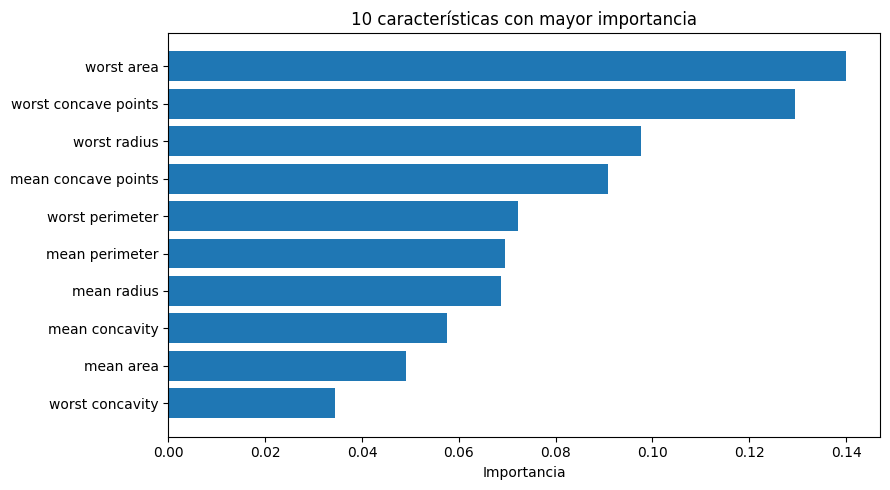

Top 5 características principales:
1. worst area: Importancia ≈ 0.140
2. worst concave points: Importancia ≈ 0.130
3. worst radius: Importancia ≈ 0.098
4. mean concave points: Importancia ≈ 0.091
5. worst perimeter: Importancia ≈ 0.072


In [6]:
importances = rf_base.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
top10_feat = feat_imp.head(10).sort_values('Importance', ascending=True)
plt.barh(top10_feat['Feature'], top10_feat['Importance'], color='#1f77b4')
plt.title('10 características con mayor importancia')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print("Top 5 características principales:")
for idx, row in feat_imp.head(5).reset_index(drop=True).iterrows():
    print(f"{idx+1}. {row['Feature']}: Importancia ≈ {row['Importance']:.3f}")

In [7]:
selector = SelectFromModel(rf_base, threshold="mean", prefit=True)
selected_features = X_train.columns[selector.get_support()]

X_train_red = selector.transform(X_train)
X_test_red = selector.transform(X_test)

print(f"Características originales: {X_train.shape[1]}")
print(f"Características seleccionadas: {len(selected_features)}")
print("Variables conservadas:")
for f in selected_features:
    print(f" - {f}")

Características originales: 30
Características seleccionadas: 10
Variables conservadas:
 - mean radius
 - mean perimeter
 - mean area
 - mean concavity
 - mean concave points
 - worst radius
 - worst perimeter
 - worst area
 - worst concavity
 - worst concave points


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [8]:
start_time = time.time()
rf_red = RandomForestClassifier(random_state=SEED)
rf_red.fit(X_train_red, y_train)
time_red = time.time() - start_time

y_pred_red = rf_red.predict(X_test_red)

acc_red = accuracy_score(y_test, y_pred_red)
recall_mal_red = recall_score(y_test, y_pred_red, pos_label=0)

print(f"Tiempo de entrenamiento: {time_red:.3f} s")
print(f"Accuracy: {acc_red*100:.2f}%")
print(f"Recall maligno: {recall_mal_red*100:.2f}%")

Tiempo de entrenamiento: 0.780 s
Accuracy: 95.61%
Recall maligno: 92.86%


In [9]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

scorer_maligno = make_scorer(recall_score, pos_label=0)

start_time = time.time()
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_grid=param_grid,
    scoring=scorer_maligno,
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train_red, y_train)
time_grid = time.time() - start_time

print(f"Tiempo de búsqueda: {time_grid:.2f} s")
print(f"Mejor configuración: {grid_search.best_params_}")
print(f"Mejor recall en CV (Maligno): {grid_search.best_score_*100:.2f}%")

Tiempo de búsqueda: 25.41 s
Mejor configuración: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Mejor recall en CV (Maligno): 93.53%


Accuracy Optimizado: 95.61%
Recall Maligno Optimizado: 92.86%



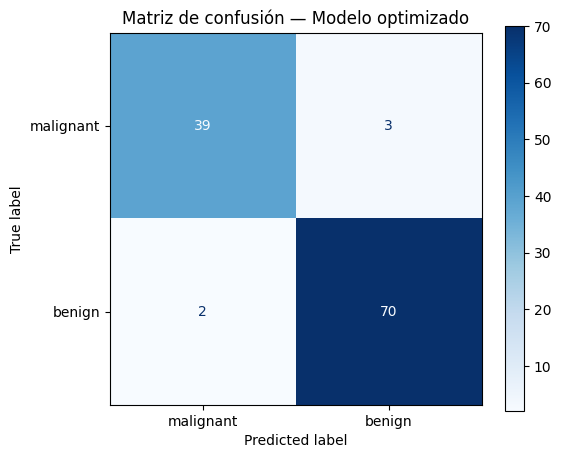

In [10]:
best_rf = grid_search.best_estimator_
y_pred_opt = best_rf.predict(X_test_red)

acc_opt = accuracy_score(y_test, y_pred_opt)
recall_mal_opt = recall_score(y_test, y_pred_opt, pos_label=0)

print(f"Accuracy Optimizado: {acc_opt*100:.2f}%")
print(f"Recall Maligno Optimizado: {recall_mal_opt*100:.2f}%\n")

cm = confusion_matrix(y_test, y_pred_opt, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['malignant', 'benign'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title('Matriz de confusión — Modelo optimizado')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

    Modelo Accuracy Recall maligno  Características Tiempo (s)
      Base   95.61%         92.86%               30      0.554
  Reducido   95.61%         92.86%               10      0.780
Optimizado   95.61%         92.86%               10     25.406


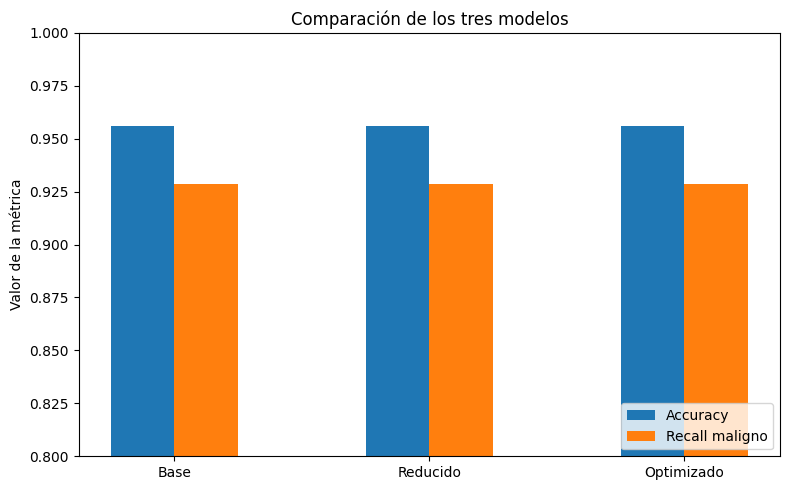

In [11]:
df_res = pd.DataFrame({
    'Modelo': ['Base', 'Reducido', 'Optimizado'],
    'Accuracy': [f"{acc_base*100:.2f}%", f"{acc_red*100:.2f}%", f"{acc_opt*100:.2f}%"],
    'Recall maligno': [f"{recall_mal_base*100:.2f}%", f"{recall_mal_red*100:.2f}%", f"{recall_mal_opt*100:.2f}%"],
    'Características': [X_train.shape[1], X_train_red.shape[1], X_train_red.shape[1]],
    'Tiempo (s)': [f"{time_base:.3f}", f"{time_red:.3f}", f"{time_grid:.3f}"]
})

print(df_res.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
width = 0.25

models = ['Base', 'Reducido', 'Optimizado']
accuracies = [acc_base, acc_red, acc_opt]
recalls = [recall_mal_base, recall_mal_red, recall_mal_opt]

ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#1f77b4')
ax.bar(x + width/2, recalls, width, label='Recall maligno', color='#ff7f0e')

ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación de los tres modelos')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0.800, 1.000)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()